<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/main/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/main/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# generators
train_ds  = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

validation_ds =  keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
)

Found 2728 files belonging to 62 classes.
Found 682 files belonging to 62 classes.


In [3]:
aug_ds = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/augmented_images/augmented_images1",
    labels="inferred",
    label_mode="int",
    batch_size=64,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

Found 13640 files belonging to 62 classes.


In [4]:
#normalize
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

In [5]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [6]:
aug_ds = aug_ds.map(process)

images, label = next(iter(aug_ds))
images.shape, label.shape

(TensorShape([64, 128, 128, 3]), TensorShape([64]))

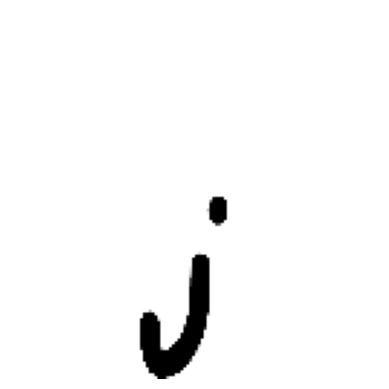

In [7]:
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [8]:
import os
import random
import numpy as np

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [9]:
images, labels = next(iter(train_ds))
images.shape, labels.shape

(TensorShape([32, 128, 128, 3]), TensorShape([32]))

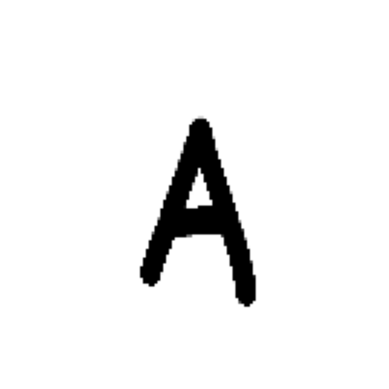

In [10]:
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [11]:
#model 1
model1 = Sequential([
    Conv2D(32, (3,3), activation= 'relu', padding = "same", input_shape = (128, 128, 3)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Conv2D(160, (3,3), activation= 'relu', padding = "same"),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),

    Dense(62, activation='softmax')
])

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10240)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,310,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,596,574 (6.09 MB)

 Trainable params: 1,596,574 (6.09 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history1 = model1.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 600s 7s/step - accuracy: 0.0561 - loss: 3.9252 - val_accuracy: 0.2038 - val_loss: 3.0700
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 222ms/step - accuracy: 0.3889 - loss: 2.3478 - val_accuracy: 0.5044 - val_loss: 1.7378
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 240ms/step - accuracy: 0.6653 - loss: 1.1730 - val_accuracy: 0.6466 - val_loss: 1.3165
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 222ms/step - accuracy: 0.7973 - loss: 0.6745 - val_accuracy: 0.6701 - val_loss: 1.3714
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - accuracy: 0.8688 - loss: 0.4282 - val_accuracy: 0.6965 - val_loss: 1.2973
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 23s 246ms/step - accuracy: 0.9267 - loss: 0.2342 - val_accuracy: 0.7053 - val_loss: 1.4300
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 229ms/step - accuracy: 0.9468 - loss: 0.1694 - val_accuracy: 0.7229 - val_loss: 1.5713
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.9652 - loss: 0.1050 - val_accura

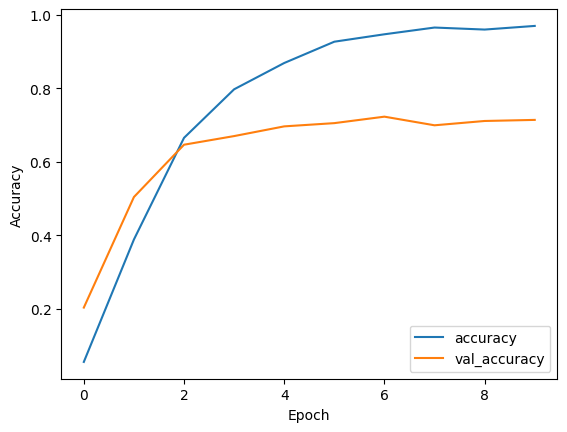

In [14]:
plt.plot(history1.history['accuracy'], label='accuracy')
plt.plot(history1.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [15]:
#model 2
model2 = Sequential([
    Conv2D(32, (3,3), activation= 'relu',  input_shape = (128, 128, 3)),

    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(64, (3,3), activation= 'relu', ),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(128, (3,3), activation= 'relu', ),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Conv2D(160, (3,3), activation= 'relu'),
    MaxPooling2D(pool_size=(2,2), strides = (2,2)),

    Flatten(),
    Dense(64, activation='relu'),

    Dense(62, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 160)    │       184,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       368,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 62)             │         4,030 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,462 (2.48 MB)

 Trainable params: 650,462 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history2 = model2.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 258ms/step - accuracy: 0.0216 - loss: 4.1006 - val_accuracy: 0.0660 - val_loss: 3.9229
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 222ms/step - accuracy: 0.1943 - loss: 3.2501 - val_accuracy: 0.4091 - val_loss: 2.2826
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 236ms/step - accuracy: 0.5029 - loss: 1.7967 - val_accuracy: 0.5704 - val_loss: 1.5544
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - accuracy: 0.6994 - loss: 1.0418 - val_accuracy: 0.6261 - val_loss: 1.3734
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 239ms/step - accuracy: 0.8035 - loss: 0.6510 - val_accuracy: 0.6657 - val_loss: 1.4194
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.8644 - loss: 0.4353 - val_accuracy: 0.6804 - val_loss: 1.4172
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 241ms/step - accuracy: 0.9040 - loss: 0.3115 - val_accuracy: 0.6818 - val_loss: 1.4704
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 19s 220ms/step - accuracy: 0.9278 - loss: 0.2313 - val_accu

In [17]:
history21= model2.fit(aug_ds, epochs=10)

Epoch 1/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 2598s 12s/step - accuracy: 0.4845 - loss: 1.9849
Epoch 2/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 382ms/step - accuracy: 0.7136 - loss: 0.9260
Epoch 3/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 83s 386ms/step - accuracy: 0.8155 - loss: 0.5681
Epoch 4/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 142s 388ms/step - accuracy: 0.8740 - loss: 0.3751
Epoch 5/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 139s 376ms/step - accuracy: 0.9131 - loss: 0.2481
Epoch 6/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 383ms/step - accuracy: 0.9383 - loss: 0.1772
Epoch 7/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 142s 382ms/step - accuracy: 0.9487 - loss: 0.1467
Epoch 8/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 382ms/step - accuracy: 0.9469 - loss: 0.1494
Epoch 9/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 382ms/step - accuracy: 0.9604 - loss: 0.1047
Epoch 10/10
214/214 ━━━━━━━━━━━━━━━━━━━━ 81s 378ms/step - accuracy: 0.9644 - loss: 0.0990


In [18]:
val_loss, val_accuracy = model2.evaluate(validation_ds)

print("Validation loss:", val_loss)
print("Validation accuracy:", val_accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - accuracy: 0.7962 - loss: 1.0632
Validation loss: 1.0632250308990479
Validation accuracy: 0.796187698841095


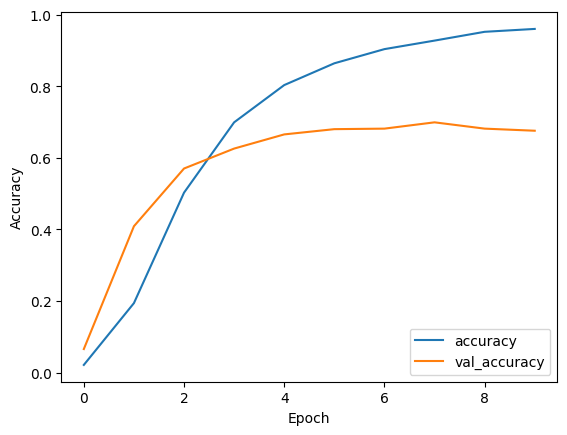

In [19]:
plt.plot(history2.history['accuracy'], label='accuracy')
plt.plot(history2.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

Our model was initially **overfitting**, which may have been partly due to the relatively **small** training dataset of around **2,000** images. With limited training data, a CNN can memorize the training examples instead of learning features that generalize well to unseen data.

To address this, we trained the model further using an **augmented dataset** containing around **13,000** images. **Data augmentation** introduced different variations of the original images, such as small rotations, shifts, and zooms, allowing the model to learn more robust features and reducing its dependence on the exact appearance of the original training images.

This approach significantly **improved** the validation accuracy from around **67.6%** to **79.62%**, showing that the additional augmented data helped the model generalize better to unseen images. However, there is still a **noticeable gap** between the training and validation performance, indicating that some **overfitting** remains.

Therefore, the next step is to experiment with **regularization techniques** such as **Dropout**. **Dropout** randomly disables some neurons/activations during training, making it more difficult for the model to memorize the training data and encouraging it to learn more robust and generalizable features.